### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Step 2: Load Data

In [7]:
df = pd.read_csv('./data/Movie_Recommender.csv', sep='\t', names=['user_id', 'item_id', 'rating', 'timestamp'])

In [9]:
movie_titles = pd.read_csv('./data/Movie_Id_Titles.csv')

In [12]:
df.shape, movie_titles.shape

((100003, 4), (1682, 2))

In [13]:
df.head()

,user_id,item_id,rating,timestamp
0,0,50,5,881250949
1,0,172,5,881250949
2,0,133,1,881250949
3,196,242,3,881250949
4,186,302,3,891717742


In [14]:
movie_titles.head()

,item_id,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)


In [16]:
df = pd.merge(df, movie_titles, on='item_id')

In [17]:
df.head()

,user_id,item_id,rating,timestamp,title
0,0,50,5,881250949,Star Wars (1977)
1,0,172,5,881250949,"Empire Strikes Back, The (1980)"
2,0,133,1,881250949,Gone with the Wind (1939)
3,196,242,3,881250949,Kolya (1996)
4,186,302,3,891717742,L.A. Confidential (1997)


### Step 3: Exploaring Data

#### Basic Info

In [24]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
user_id,100003.0,4.624709e+02,2.666225e+02,0.0,254.0,447.0,682.0,943.0
item_id,100003.0,4.255209e+02,3.307978e+02,1.0,175.0,322.0,631.0,1682.0
rating,100003.0,3.529864e+00,1.125704e+00,1.0,3.0,4.0,4.0,5.0
timestamp,100003.0,8.835288e+08,5.343791e+06,874724710.0,879448715.0,882826944.0,888259984.0,893286638.0


In [25]:
feature_info = pd.DataFrame(
    {
        'null': df.isnull().sum(),
        'null(%)': round(df.isnull().sum() / len(df)),
        'unique': df.nunique(),
        'type': df.dtypes
    }
)

In [26]:
feature_info

,null,null(%),unique,type
user_id,0,0.0,944,int64
item_id,0,0.0,1682,int64
rating,0,0.0,5,int64
timestamp,0,0.0,49282,int64
title,0,0.0,1664,object


In [33]:
rating_df = pd.DataFrame(
    {
        'rating': df.groupby('title')['rating'].mean(),
        'count': df.groupby('title')['rating'].count()
    }
)

In [43]:
rating_df.sort_values('count', ascending=False).head()

,rating,count
title,,
Star Wars (1977),4.359589,584
Contact (1997),3.803536,509
Fargo (1996),4.155512,508
Return of the Jedi (1983),4.007890,507
Liar Liar (1997),3.156701,485


#### Feature Distribution

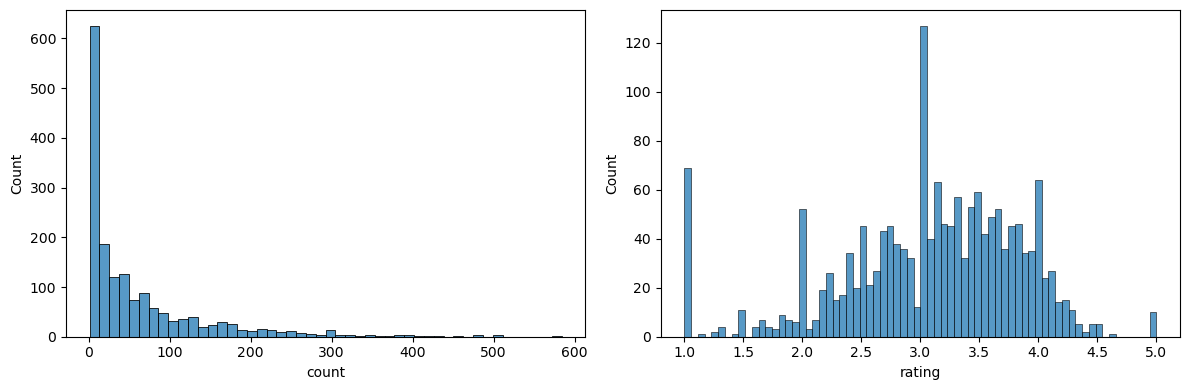

In [40]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(x='count', data=rating_df)
plt.subplot(1, 2, 2)
sns.histplot(x='rating', data=rating_df, bins=70)
plt.tight_layout()

### Step 4: Movie Recommender

In [42]:
movie_mat = df.pivot_table(
    index ='user_id',
    columns ='title', 
    values ='rating'
)

In [107]:
def movie_recommender(movie_name):
    corr_moive = movie_mat.corr()[movie_name].dropna().sort_values(ascending=False)
    corr_moive = corr_moive.drop(index=movie_name)
    corr_moive = pd.DataFrame({'corr': corr_moive}).join(rating_df['count'])
    return corr_moive[corr_moive['count'] > 100].sort_values('corr', ascending = False).head()

In [108]:
movie_recommender('Star Wars (1977)')

,corr,count
title,,
"Empire Strikes Back, The (1980)",0.748353,368
Return of the Jedi (1983),0.672556,507
Raiders of the Lost Ark (1981),0.536117,420
Austin Powers: International Man of Mystery (1997),0.377433,130
"Sting, The (1973)",0.367538,241


In [110]:
movie_recommender('Return of the Jedi (1983)')

,corr,count
title,,
"Empire Strikes Back, The (1980)",0.721229,368
Star Wars (1977),0.672556,584
Raiders of the Lost Ark (1981),0.467391,420
Indiana Jones and the Last Crusade (1989),0.422294,331
Sneakers (1992),0.412559,150
